<a href="https://colab.research.google.com/github/reysanil23/MoneyBallProject/blob/main/MoneyballProjectNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook: Putting the "money" in Moneyball
In this notebook we will:
* look at the new `batting` and `salaries` dataset
* understand how to merge different datasets
* use machine learning to predict salaries
* identify undervalued players

# Milestone 1: Introducing the `batting` and `salaries` datasets

In [ ]:
#@title Run this to download data and prepare our environment!
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# ------------------ BATTING ------------------
batting = pd.read_csv("https://drive.google.com/uc?id=17IM9kxyscGEpu-4Ov5p7MpCKz9UVHLla")

# Rename columns to be more descriptive
abbrev_map = {
    "R" : "Runs",
    "AB" : "AtBats",

    "H"  : "Hits",
    "2B" : "Doubles",
    "3B" : "Triples",
    "HR" : "HomeRuns",
    "RBI": "RunsBattedIn",

    "BB"  : "Walks",
    "IBB" : "IntentionalWalks",
    "HBP" : "HitsByPitch",
    "SF"  : "SacrificeFlies",
    "SH"  : "SacrificeHits",

    "SB"   : "StolenBases",
    "CS"   : "CaughtStealing",
    "SO"   : "Strikeouts",
    "GIDP" : "GroundedIntoDoublePlays",

    "W" : "Wins",
    "L" : "Losses",
    "G" : "Games",
}

batting = batting.rename(columns=abbrev_map)
batting = batting.loc[batting["AtBats"] > 130] # remove rookies' rows

# Take data from multiple stints and put it in one row
batting = batting.groupby(['playerID', 'yearID']).sum(numeric_only=True)
batting = batting.sort_values(['playerID', 'yearID'])
batting = batting.reset_index()
batting = batting.drop(columns='stint')

# Add in number of seasons played
seasonsPlayed = batting.groupby('playerID')['yearID'].cumcount()
batting.insert(batting.columns.get_loc('yearID') + 1, 'SeasonsPlayed', seasonsPlayed)


# Add in features from NB1
batting["BattingAverage"] = batting.eval("Hits / AtBats")
batting["OnBasePercentage"] = batting.eval("(Hits + Walks + HitsByPitch) / (AtBats + Walks + HitsByPitch + SacrificeFlies)")
batting["SluggingPercentage"] = batting.eval("(Hits + Doubles + 2*Triples + 3*HomeRuns) / AtBats")


# ------------------ SALARIES ------------------
# load in salaries data
salaries = pd.read_csv("https://drive.google.com/uc?id=16wlS8fmyZ43sATfeSZ8eUAqR5543pg_G")
salaries = salaries.loc[salaries['salary'] > 0]
salaries = salaries.drop(columns="lgID")

# Remove players with multiple stints
salaries = salaries[~salaries.duplicated(subset=['playerID', 'yearID'], keep=False)]

# For people's names
people = pd.read_csv("https://drive.google.com/uc?id=1QkDGU9p0L1JqiubZwQl_ZqVbGltbWwKF")

## Exploring the Batting Dataset

We'll start by focusing on individual player performance. The `batting` dataset offers a wealth of information about players' batting statistics. *Note that this is different from the `teams` dataset we were using in the previous notebook, since this includes statistics for each player each year they played!*



In [ ]:
pd.set_option('display.max_columns', None)
batting.head(9)

,playerID,yearID,SeasonsPlayed,Games,AtBats,Runs,Hits,Doubles,Triples,HomeRuns,RunsBattedIn,StolenBases,CaughtStealing,Walks,Strikeouts,IntentionalWalks,HitsByPitch,SacrificeHits,SacrificeFlies,GroundedIntoDoublePlays,BattingAverage,OnBasePercentage,SluggingPercentage
0,aaronha01,1954,0,122,468,58,131,27,6,13,69.0,2.0,2.0,28,39.0,0.0,3.0,6.0,4.0,13.0,0.279915,0.322068,0.446581
1,aaronha01,1955,1,153,602,105,189,37,9,27,106.0,3.0,1.0,49,61.0,5.0,3.0,7.0,4.0,20.0,0.313953,0.366261,0.539867
2,aaronha01,1956,2,153,609,106,200,34,14,26,92.0,2.0,4.0,37,54.0,6.0,2.0,5.0,7.0,21.0,0.328407,0.364885,0.558292
3,aaronha01,1957,3,151,615,118,198,27,6,44,132.0,1.0,1.0,57,58.0,15.0,0.0,0.0,3.0,13.0,0.321951,0.377778,0.600000
4,aaronha01,1958,4,153,601,109,196,34,4,30,95.0,4.0,1.0,59,49.0,16.0,1.0,0.0,3.0,21.0,0.326123,0.385542,0.545757
5,aaronha01,1959,5,154,629,116,223,46,7,39,123.0,8.0,0.0,51,54.0,17.0,4.0,0.0,9.0,19.0,0.354531,0.401154,0.635930
6,aaronha01,1960,6,153,590,102,172,20,11,40,126.0,16.0,7.0,60,63.0,13.0,2.0,0.0,12.0,8.0,0.291525,0.352410,0.566102
7,aaronha01,1961,7,155,603,115,197,39,10,34,120.0,21.0,9.0,56,64.0,20.0,2.0,1.0,9.0,16.0,0.326700,0.380597,0.593698
8,aaronha01,1962,8,156,592,127,191,28,6,45,128.0,15.0,7.0,66,73.0,14.0,3.0,0.0,6.0,14.0,0.322635,0.389805,0.618243


## Adding in Seniority


Adding features that will tell us if our baseball players are arbitration eligible or free agents. Here are some descriptions:

- **Arbitration Eligible**: In baseball, players become eligible for arbitration after three to six years of service time. During arbitration, players negotiate contracts with their teams for the upcoming season, or an arbitrator decides on a salary if an agreement isn't reached.

- **Free Agent**: In baseball, a free agent is a player not under contract with any team, allowing them to sign with any team they choose. Free agency typically occurs when a player's contract expires, or after they've completed six years of service time in the Major Leagues, granting them the freedom to negotiate new contracts with various teams.


Why might adding these columns in be important for our later salary prediction?

### ✍ Adding in the Seniority Columns


In [ ]:
batting["isArbitrationEligible"] = (3 <= batting["SeasonsPlayed"]) & (batting["SeasonsPlayed"] < 6)
batting["isFreeAgent"] = 6 <= batting["SeasonsPlayed"]
batting["isRookie"] = (batting["SeasonsPlayed"] < 3)
batting.head(9)

,playerID,yearID,SeasonsPlayed,Games,AtBats,Runs,Hits,Doubles,Triples,HomeRuns,RunsBattedIn,StolenBases,CaughtStealing,Walks,Strikeouts,IntentionalWalks,HitsByPitch,SacrificeHits,SacrificeFlies,GroundedIntoDoublePlays,BattingAverage,OnBasePercentage,SluggingPercentage,isArbitrationEligible,isFreeAgent,isRookie
0,aaronha01,1954,0,122,468,58,131,27,6,13,69.0,2.0,2.0,28,39.0,0.0,3.0,6.0,4.0,13.0,0.279915,0.322068,0.446581,False,False,True
1,aaronha01,1955,1,153,602,105,189,37,9,27,106.0,3.0,1.0,49,61.0,5.0,3.0,7.0,4.0,20.0,0.313953,0.366261,0.539867,False,False,True
2,aaronha01,1956,2,153,609,106,200,34,14,26,92.0,2.0,4.0,37,54.0,6.0,2.0,5.0,7.0,21.0,0.328407,0.364885,0.558292,False,False,True
3,aaronha01,1957,3,151,615,118,198,27,6,44,132.0,1.0,1.0,57,58.0,15.0,0.0,0.0,3.0,13.0,0.321951,0.377778,0.600000,True,False,False
4,aaronha01,1958,4,153,601,109,196,34,4,30,95.0,4.0,1.0,59,49.0,16.0,1.0,0.0,3.0,21.0,0.326123,0.385542,0.545757,True,False,False
5,aaronha01,1959,5,154,629,116,223,46,7,39,123.0,8.0,0.0,51,54.0,17.0,4.0,0.0,9.0,19.0,0.354531,0.401154,0.635930,True,False,False
6,aaronha01,1960,6,153,590,102,172,20,11,40,126.0,16.0,7.0,60,63.0,13.0,2.0,0.0,12.0,8.0,0.291525,0.352410,0.566102,False,True,False
7,aaronha01,1961,7,155,603,115,197,39,10,34,120.0,21.0,9.0,56,64.0,20.0,2.0,1.0,9.0,16.0,0.326700,0.380597,0.593698,False,True,False
8,aaronha01,1962,8,156,592,127,191,28,6,45,128.0,15.0,7.0,66,73.0,14.0,3.0,0.0,6.0,14.0,0.322635,0.389805,0.618243,False,True,False


# Examining the Salaries Dataset

The `salaries` dataset provides detailed information about the salaries of baseball players.


In [ ]:
salaries.head()

### ✍ Exploring Summary Statistics

 The `.describe()` method will provide key statistical measures for each column in the dataset, such as mean, standard deviation, minimum, maximum, and quartile values.


In [ ]:
salaries.describe()

,yearID,salary
count,26216.000000,2.621600e+04
mean,2000.925427,2.097156e+06
std,8.918734,3.465773e+06
min,1985.000000,1.090000e+04
25%,1994.000000,3.000000e+05
50%,2001.000000,5.500000e+05
75%,2009.000000,2.368985e+06
max,2016.000000,3.300000e+07


### ✍ Plotting the Salary Data

A histogram is a type of plot that allows to plot how frequently values occur in a dataset. The $x$-axis will represent the data values of interest, while the $y$-axis will represent the counts!


<Axes: xlabel='salary', ylabel='Count'>

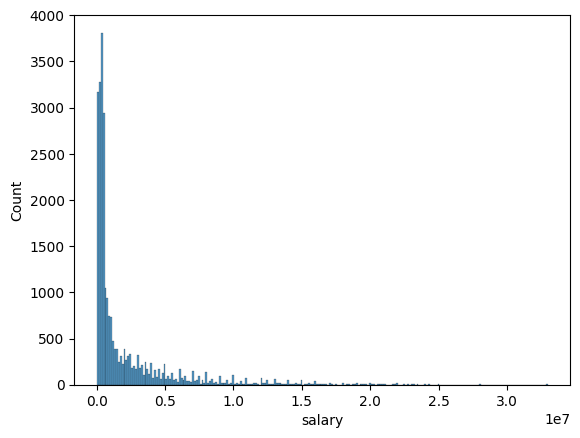

In [ ]:
sns.histplot(x="salary", data=salaries)

### ✍ Transforming Salary Data with Logarithm

- Create a new column in the `salaries` dataset named `"LogSalary"`.
- This column should contain the logarithm of each player's salary.
- Once the new column is added, plot the distribution of the transformed salaries.


<Axes: xlabel='LogSalary', ylabel='Count'>

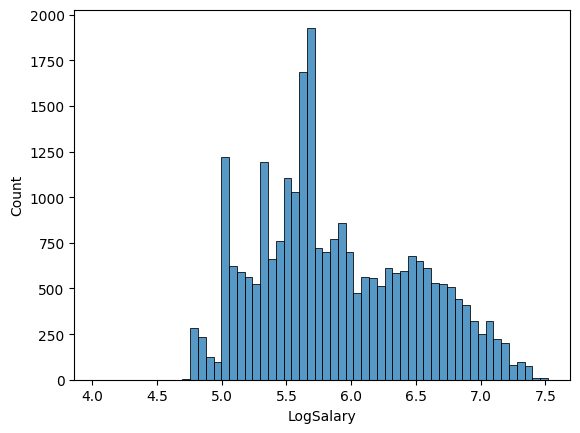

In [ ]:
salaries["LogSalary"] = np.log10(salaries["salary"])
sns.histplot(x="LogSalary", data=salaries)

### ✍ Examining Our Year Feature

We'll make a new column `yearID_salary` in the `batting` dataset so that we can link a player's batting data in one year to his salary the following year.


In [ ]:
batting['yearID_salary'] = batting['yearID'] + 1
batting.head(1)

,playerID,yearID,SeasonsPlayed,Games,AtBats,Runs,Hits,Doubles,Triples,HomeRuns,RunsBattedIn,StolenBases,CaughtStealing,Walks,Strikeouts,IntentionalWalks,HitsByPitch,SacrificeHits,SacrificeFlies,GroundedIntoDoublePlays,BattingAverage,OnBasePercentage,SluggingPercentage,isArbitrationEligible,isFreeAgent,isRookie,yearID_salary
0,aaronha01,1954,0,122,468,58,131,27,6,13,69.0,2.0,2.0,28,39.0,0.0,3.0,6.0,4.0,13.0,0.279915,0.322068,0.446581,False,False,True,1955


In [ ]:
salaries = salaries.rename(columns={'yearID': 'yearID_salary', 'teamID': 'teamID_salary'})
salaries.head(1)

,yearID_salary,teamID_salary,playerID,salary,LogSalary
0,1985,ATL,barkele01,870000,5.939519


## Merging Datasets: Linking Player Data with Salaries

By merging these datasets, we'll be able to conduct more holistic analyses, such as assessing the impact of specific performance metrics on salary and exploring trends in player compensation over time.



### ✍ Merging the Datasets


In [ ]:
merged_data = pd.merge(batting, salaries, on=['yearID_salary','playerID'])
merged_data.head()

,playerID,yearID,SeasonsPlayed,Games,AtBats,Runs,Hits,Doubles,Triples,HomeRuns,RunsBattedIn,StolenBases,CaughtStealing,Walks,Strikeouts,IntentionalWalks,HitsByPitch,SacrificeHits,SacrificeFlies,GroundedIntoDoublePlays,BattingAverage,OnBasePercentage,SluggingPercentage,isArbitrationEligible,isFreeAgent,isRookie,yearID_salary,teamID_salary,salary,LogSalary
0,abbotje01,1998,0,89,244,33,68,14,1,12,41.0,3.0,3.0,9,28.0,1.0,0.0,2.0,5.0,2.0,0.278689,0.298450,0.491803,False,False,True,1999,CHA,255000,5.406540
1,abbotje01,2000,1,80,215,31,59,15,1,3,29.0,2.0,1.0,21,38.0,1.0,2.0,2.0,1.0,2.0,0.274419,0.343096,0.395349,False,False,True,2001,FLO,300000,5.477121
2,abbotku01,1994,0,101,345,41,86,17,3,9,33.0,3.0,0.0,16,98.0,1.0,5.0,3.0,2.0,5.0,0.249275,0.290761,0.394203,False,False,True,1995,FLO,119000,5.075547
3,abbotku01,1995,1,120,420,60,107,18,7,17,60.0,4.0,3.0,36,110.0,4.0,5.0,2.0,5.0,6.0,0.254762,0.317597,0.452381,False,False,True,1996,FLO,250000,5.397940
4,abbotku01,1996,2,109,320,37,81,18,7,8,33.0,3.0,3.0,22,99.0,1.0,3.0,4.0,0.0,7.0,0.253125,0.307246,0.428125,False,False,True,1997,FLO,650000,5.812913


# Milestone 2: Salary Prediction

- Achieve a high degree of accuracy in salary predictions.
- Understand the factors that most significantly influence player salaries.
- Explore the relationship between player performance, experience, and compensation.



### Choosing the columns to focus on


In [ ]:
#@title Run this to choose the columns
#@markdown NOTE: as you toggle the columns below, your `X` dataset will automatically update! Keep note of this if you change things after trying out your models below.
from ipywidgets import widgets
from sklearn.preprocessing import MinMaxScaler

# Create checkboxes for each column
checkboxes = {col:
                widgets.Checkbox(description=col, value=(col not in ['salary', 'LogSalary', 'playerID', 'teamID_salary']))
                for col in merged_data.columns}

# Initial selection
bool_list = [checkboxes[col].value for col in merged_data.columns]
X = merged_data.loc[:, bool_list]
X_scaled = MinMaxScaler().fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)
y = merged_data["LogSalary"]

# Function to update selected_columns based on checkbox values
def update_selected_columns(change):
  global X, bool_list
  bool_list = [checkboxes[col].value for col in merged_data.columns]
  X = merged_data.loc[:, bool_list]
  X_scaled = MinMaxScaler().fit_transform(X)
  X = pd.DataFrame(X_scaled, columns=X.columns)

# Attach the callback to checkbox changes
for checkbox in checkboxes.values():
    checkbox.observe(update_selected_columns, 'value')

# Display checkboxes in a grid
widgets.GridBox(list(checkboxes.values()), layout=widgets.Layout(grid_template_columns="repeat(3, 200px)"))

GridBox(children=(Checkbox(value=False, description='playerID'), Checkbox(value=True, description='yearID'), C…

Last step is to split the data as always! Why do we need to do this?

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### ✍ Initializing and fitting the model


In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)


LinearRegression()

### ✍ Evaluating the model


In [ ]:
linear_model.score(X_test, y_test)

0.7665564671594285

In [ ]:
predictions = linear_model.predict(X_test)
mean_squared_error(y_test, predictions)

0.07777850870207033

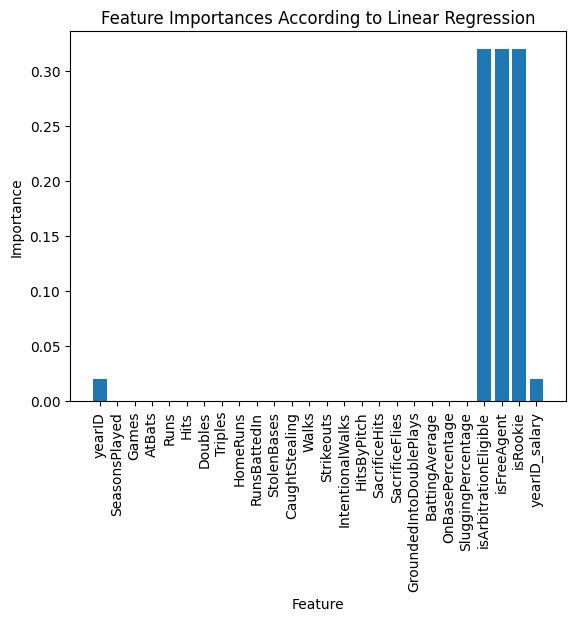

In [ ]:
#@title Run this to see the linear regression model importances!

# Get absolute values of the coefficients of the model
linear_model_importances = np.abs(linear_model.coef_)

# Normalize feature importances
linear_model_importances /= linear_model_importances.sum()

# Plot feature importances
plt.bar(X.columns, linear_model_importances, label='Linear Regression')
plt.title('Feature Importances According to Linear Regression')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.show()

## ✍ Decision Tree!


In [ ]:
dt_model = DecisionTreeRegressor(max_depth=3)
dt_model.fit(X_train, y_train)
predictions = dt_model.predict(X_test)
print(mean_squared_error(y_test, predictions))
print(dt_model.score(X_test, y_test))



0.10818980953294835
0.6752803341670688


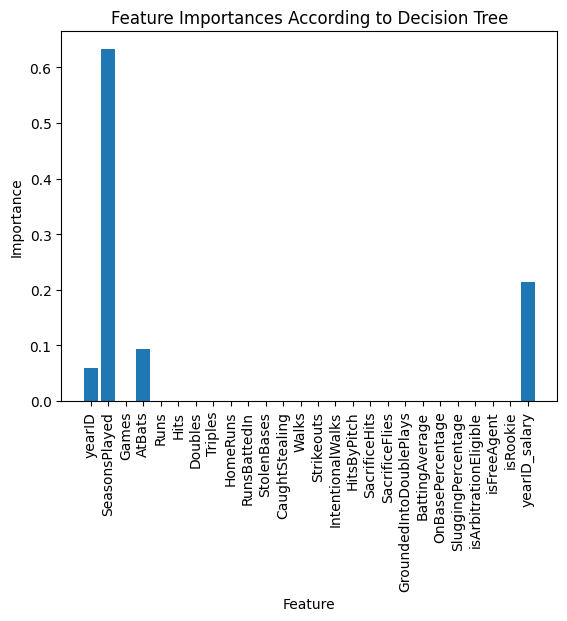

In [ ]:
#@title Run this to see the decision tree model importances!

# Get absolute values of the coefficients of the model
dt_importances = dt_model.feature_importances_

# Plot feature importances
plt.bar(X.columns, dt_importances)
plt.title('Feature Importances According to Decision Tree')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=90)
plt.show()

## Exploring Other Models

- `RandomForestRegressor`: basically a "forest" of decision trees that are each fit on different samples of the data. We determine the prediction by feeding the input to all the trees and taking the average of their predictions.
- `MLPRegressor`: a fully connected neural network. Remember to specify the hidden layer structure using the `hidden_layer_sizes` parameter!
-

In [ ]:
models = [RandomForestRegressor(max_depth = 6), MLPRegressor(hidden_layer_sizes=(64,32)),]

for model in models:
  model.fit(X_train, y_train)
  predictions = model.predict(X_test)
  print(model.score(X_test,y_test))
  print(mean_squared_error(y_test, predictions))

0.8027311664077029
0.06572585457179624
0.8184362734642991
0.06049324096710649


# Milestone 3: Determining the most undervalued players

To identify the most undervalued players, we will take a look at the predicted `LogSalary` and compare it to the actual value. In the code cell below, make a new column called `LogSalaryDifference` that is the result of subtracting the true `LogSalary` from the prediction of your chosen model.

In [ ]:
predictions = linear_model.predict(X)
merged_data['LogSalaryDifference'] = merged_data['LogSalary'] - predictions

Now what does this difference really mean? Let's dive back into the math. Here's what we have above:

$$ \text{LogSalaryDifference} = \log_{10}(\text{salary}_{\text{pred}}) - \log_{10}(\text{salary}_{\text{true}}) $$

A nifty rule of logarithms is that this is equivalent to

$$ \text{LogSalaryDifference} = \log_{10} \left( \frac{ \text{salary}_{\text{pred}} }{ \text{salary}_{\text{true}} } \right)$$

Another nifty rule of the logarithm we're using is that

\begin{align}
10^{\log_{10} x} = x
\end{align}

Putting all of this together, we have the following:

\begin{align}
10^\text{LogSalaryDifference} &= 10^{\log_{10} \left( \frac{ \text{salary}_{\text{pred}} }{ \text{salary}_{\text{true}} } \right)} \\
&= \frac{ \text{salary}_{\text{pred}} }{ \text{salary}_{\text{true}} }
\end{align}

meaning we can get the ratio of the predicted salary to the true salary by taking the exponent of our `LogSalaryDifference` column!



In [ ]:
merged_data['SalaryRatio'] = np.power(10, merged_data['LogSalaryDifference'])

Run the cell below to sort the data by this ratio! What do values above 1 mean? What about below 1? Who are the most under- and overvalued players based on our model?

In [ ]:
merged_data.sort_values('SalaryRatio')

,playerID,yearID,SeasonsPlayed,Games,AtBats,Runs,Hits,Doubles,Triples,HomeRuns,RunsBattedIn,StolenBases,CaughtStealing,Walks,Strikeouts,IntentionalWalks,HitsByPitch,SacrificeHits,SacrificeFlies,GroundedIntoDoublePlays,BattingAverage,OnBasePercentage,SluggingPercentage,isArbitrationEligible,isFreeAgent,isRookie,yearID_salary,teamID_salary,salary,LogSalary,LogSalaryDifference,SalaryRatio
259,armasto01,1986,9,121,425,40,112,21,4,11,58.0,0.0,3.0,24,77.0,1.0,2.0,0.0,2.0,12.0,0.263529,0.304636,0.409412,False,True,False,1987,CAL,62500,4.795880,-1.133807,0.073484
180,anderbr01,2001,13,131,430,50,87,12,3,8,45.0,12.0,4.0,60,77.0,4.0,8.0,2.0,1.0,3.0,0.202326,0.310621,0.300000,False,True,False,2002,CLE,200000,5.301030,-1.118892,0.076052
9395,uptonbj01,2008,3,145,531,85,145,37,2,9,67.0,44.0,16.0,97,134.0,4.0,2.0,3.0,7.0,13.0,0.273070,0.383046,0.401130,True,False,False,2009,TBA,435000,5.638489,-1.097839,0.079829
1834,clarkja01,1992,15,81,257,32,54,11,0,5,33.0,1.0,1.0,56,87.0,3.0,2.0,0.0,5.0,4.0,0.210117,0.350000,0.311284,False,True,False,1993,MON,109000,5.037426,-1.081714,0.082849
4242,henderi01,2000,21,92,324,58,77,13,2,4,30.0,31.0,9.0,63,55.0,0.0,2.0,3.0,3.0,9.0,0.237654,0.362245,0.327160,False,True,False,2001,SDN,300000,5.477121,-1.071707,0.084780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3805,guerral01,2015,0,106,219,25,51,9,1,11,36.0,1.0,0.0,7,57.0,0.0,2.0,0.0,2.0,7.0,0.232877,0.260870,0.433790,False,False,True,2016,LAN,7500000,6.875061,1.101624,12.636412
8304,sandede02,1992,1,97,303,54,92,6,14,8,28.0,26.0,9.0,18,52.0,0.0,2.0,1.0,1.0,5.0,0.303630,0.345679,0.495050,False,False,True,1993,ATL,3166667,6.500602,1.176384,15.010102
8305,sandede02,1993,2,95,272,42,75,18,6,6,28.0,19.0,7.0,16,42.0,3.0,3.0,1.0,2.0,3.0,0.275735,0.320819,0.452206,False,False,True,1994,ATL,3632513,6.560207,1.226223,16.835375
3159,fukudko01,2010,2,130,358,45,94,20,2,13,44.0,7.0,8.0,64,67.0,1.0,0.0,3.0,4.0,5.0,0.262570,0.370892,0.438547,False,False,True,2011,CHN,14500000,7.161368,1.264884,18.402788
